In [ ]:
# Importing packages
import cv2
import numpy as np
import os
from zipfile import ZipFile
import shutil
import re
import random
import pandas as pd
from keras.layers import Input, TimeDistributed, Conv2D, LSTM, Flatten, MaxPool2D, Dense, Dropout, Lambda
from keras.models import Model, load_model
from keras.optimizers import Adam
from keras.utils import plot_model

Getting the Train, Validation and Test annotations:

In [ ]:
with ZipFile('train-annotation.zip') as zf:
    zf.extractall()

In [ ]:
with ZipFile('val-annotation-e.zip') as zf:
    zf.extractall(pwd=b'zeAzLQN7DnSIexQukc9W') # password for validation annotations

In [ ]:
with ZipFile('test-annotation-e.zip') as zf:
    zf.extractall(pwd=b'zeAzLQN7DnSIexQukc9W') # password for test annotations

Extracting Train, Validation and Test image frames for the videos:

In [ ]:
# Training image frames:
with ZipFile('frames.zip') as zf:
  zf.extractall()

In [ ]:
# Validation image frames:
with ZipFile('val_frames.zip') as zf:
  zf.extractall()

In [ ]:
# Test image frames:
with ZipFile('test_frames.zip') as zf:
  zf.extractall()

In [ ]:
print('Number of videos in training data: ', len(os.listdir('content/frames')))
print('Number of videos in validation data: ', len(os.listdir('content/val_frames')))
print('Number of videos in test data: ', len(os.listdir('content/test_frames')))

Number of videos in training data:  960
Number of videos in validation data:  160
Number of videos in test data:  160


In [ ]:
h = w = 224 # Height and Width of the Image
c = 3 # Number of Channels
time_steps = 15 # Frames extracted from the video

Generator function:

In [ ]:
# Generator function to produce mini batches of the data
def get_batches(flag = 'train', b_size = 16):
  count = 0 # counter variable

  if flag == 'validation': # val set
    path_ = 'content/val_frames/' # Path to validation data
    anot = pd.read_pickle('annotation_validation.pkl') # Getting the validation scores

  else: # train
    path_ = 'content/frames/' # Path to train data
    anot = pd.read_pickle('annotation_training.pkl') # Getting the train scores

  data = os.listdir(path_) # list of all videos
  random.shuffle(data)

  while True:
    # looping over all videos
    while count < len(data):

      all_frames = np.empty((0,time_steps,h,w,c)) # numpy array of batch of videos
      labels = np.empty((0,5)) # numpy array to contain the 5 personality scores

      if (count + b_size) <= len(data):
        batch_size = b_size
      else:
        batch_size = len(data) % b_size # incase when len(data) is not a multiple of batch_size

      for i in range(batch_size):
        # getting names of all image frames in folder for i th video
        f_name = os.listdir(path_ + data[count])
        # sorting the image frame names sequentially
        f_name.sort(key= lambda x: int(re.findall(r'[_][\d]+',x)[0].split('_')[1]))
        frames_1 = [] # list to contain array of all image frames of the ith video
        for j in f_name: # looping over all frames in the ith video
          img = cv2.imread(path_ + data[count] +'/'+ j)
          frames_1.append(img) # appending each frame array

        # stacking all frames in the batch after scaling each frame
        all_frames = np.vstack((all_frames,(np.array(frames_1)/255)[np.newaxis,...]))


        # extracting the labels
        l = np.array([anot['extraversion'][data[count]+'.mp4'],anot['neuroticism'][data[count]+'.mp4'],anot['agreeableness'][data[count]+'.mp4'],anot['conscientiousness'][data[count]+'.mp4'],anot['openness'][data[count]+'.mp4']])
        labels = np.vstack((labels,l[np.newaxis,...]))

        count += 1

  # after every epoch the counter must start again
      if count >= len(data):
        count = 0
        random.shuffle(data)

      yield [all_frames, labels]  # should yield input of the model in one list


In [ ]:
# Making objects for the train and validation generator
train_batches = get_batches(flag = 'train', b_size = 16)
val_batches = get_batches(flag = 'validation', b_size = 16)

### Model Architecture:

The model to be used is a VGG16 Model - using transfer learning - followed by an LSTM:

In [ ]:
import keras
from keras.layers import Dense, LSTM, Flatten, TimeDistributed, Conv2D, Dropout
from keras import Sequential
from keras.applications.vgg16 import VGG16
from keras.optimizers import SGD

In [ ]:
# creating a VGG16 model, using image with shape (h, w, c)
vgg = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(h, w, c)
)
# only training the 4 last layers
for layer in vgg.layers[:-4]:
    layer.trainable = False
# creating a Sequential model
model = Sequential()
# adding vgg model for 15 input images
model.add(
    TimeDistributed(vgg, input_shape=(time_steps, h, w, c))
)
# Flatten output to send to LSTM with one dimension
model.add(
    TimeDistributed(Flatten())
)
model.add(LSTM(256, return_sequences = False))
# finalize with Dense, Dropout layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='sigmoid'))

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_4 (TimeDis  (None, 15, 7, 7, 512)    14714688  
 tributed)                                                       
                                                                 
 time_distributed_5 (TimeDis  (None, 15, 25088)        0         
 tributed)                                                       
                                                                 
 lstm_2 (LSTM)               (None, 256)               25953280  
                                                                 
 dense_4 (Dense)             (None, 64)                16448     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 5)                

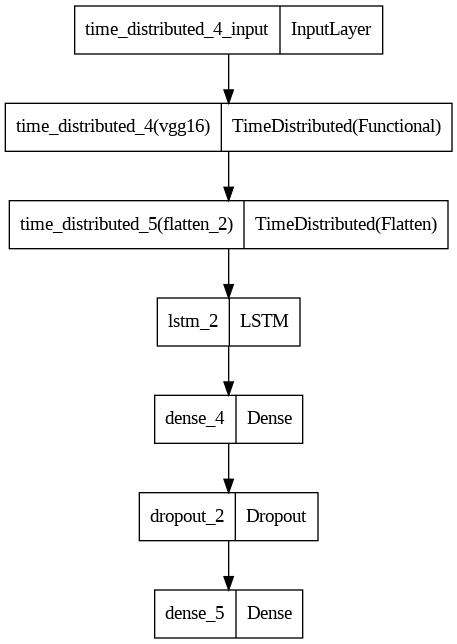

In [ ]:
model.summary()
plot_model(model)

In [ ]:
# Compiling the Model
model.compile(loss = "mean_squared_error", optimizer= Adam(0.00001), metrics = ['acc'])

In [ ]:
# Training the model

history_1 = model.fit_generator(train_batches, validation_data = val_batches, epochs=20, steps_per_epoch = (960 - 48) // 8, validation_steps= (160 - 11) // 8)

<ipython-input-37-b39af6c9b637>:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history_1 = model.fit_generator(train_batches, validation_data = val_batches, epochs=20, steps_per_epoch = (960 - 48) // 8, validation_steps= (160 - 11) // 8)


Epoch 1/20
114/114 [==============================] - 329s 3s/step - loss: 0.0234 - acc: 0.2703 - val_loss: 0.0192 - val_acc: 0.3160
Epoch 2/20
114/114 [==============================] - 199s 2s/step - loss: 0.0175 - acc: 0.3207 - val_loss: 0.0180 - val_acc: 0.3264
Epoch 3/20
114/114 [==============================] - 212s 2s/step - loss: 0.0148 - acc: 0.3481 - val_loss: 0.0184 - val_acc: 0.3576
Epoch 4/20
114/114 [==============================] - 199s 2s/step - loss: 0.0123 - acc: 0.3662 - val_loss: 0.0168 - val_acc: 0.3264
Epoch 5/20
114/114 [==============================] - 198s 2s/step - loss: 0.0103 - acc: 0.3975 - val_loss: 0.0172 - val_acc: 0.3472
Epoch 6/20
114/114 [==============================] - 212s 2s/step - loss: 0.0094 - acc: 0.4353 - val_loss: 0.0181 - val_acc: 0.3125
Epoch 7/20
114/114 [==============================] - 211s 2s/step - loss: 0.0087 - acc: 0.4671 - val_loss: 0.0172 - val_acc: 0.4097
Epoch 8/20
114/114 [==============================] - 211s 2s/step - 

In [ ]:
# Convert the history.history dict to a pandas DataFrame:
hist_df = pd.DataFrame(history_1.history)

# and save to csv:
hist_csv_file = '/content/hist_vid.csv'
with open(hist_csv_file, mode='w') as f:
    hist_df.to_csv(f)

In [ ]:
model.save('mod_vid.h5') # Saving the model

In [ ]:
model = load_model('mod_vid.h5') # load model

In [ ]:
# Generator function for the test data set

count = 0 # counter variable

path_ = 'content/test_frames/' # Path to test data
anot = pd.read_pickle('annotation_test.pkl') # Getting the test scores

data = os.listdir(path_)

labels = []
pred =[]
mean_acc_test = []

# looping over all test videos
while count < len(data):

  f_name = os.listdir(path_ + data[count]) # getting names of all frames in video folder
  f_name.sort(key= lambda x: int(re.findall(r'[_][\d]+',x)[0].split('_')[1])) # sorting the frame names sequentially

  frames_1 = [] # list to contain array of all farmes
  for j in f_name: # looping over all frames in a video
      img = cv2.imread(path_ +data[count] +'/'+j)
      frames_1.append(img) # appending each frame array
  frames_1 = np.array(frames_1)/255

  # extracting the labels
  l = np.array([anot['extraversion'][data[count]+'.mp4'],anot['neuroticism'][data[count]+'.mp4'],anot['agreeableness'][data[count]+'.mp4'],anot['conscientiousness'][data[count]+'.mp4'],anot['openness'][data[count]+'.mp4']])
  labels.append(l)

  p = model.predict([frames_1[np.newaxis,...]])
  pred.append(p)

  mean_acc_test.append(np.mean(1-np.absolute(l-p)))
  count += 1

  if count % 10 == 0:
    print(count)

1/1 [==============================] - 0s 34ms/step
10
1/1 [==============================] - 0s 26ms/step
20
1/1 [==============================] - 0s 24ms/step
30
1/1 [==============================] - 0s 24ms/step
40
1/1 [==============================] - 0s 27ms/step
50
1/1 [==============================] - 0s 27ms/step
60
1/1 [==============================] - 0s 29ms/step
70
1/1 [==============================] - 0s 34ms/step
80
1/1 [==============================] - 0s 40ms/step
90
1/1 [==============================] - 0s 25ms/step
100
1/1 [==============================] - 0s 31ms/step
110
1/1 [==============================] - 0s 24ms/step
120
1/1 [==============================] - 0s 26ms/step
130
1/1 [==============================] - 0s 23ms/step
140
1/1 [==============================] - 0s 23ms/step
150
1/1 [==============================] - 0s 25ms/step
160


In [ ]:
np.mean(mean_acc_test) # Getting the Total Mean Accuracy

0.8903594328896777

In [ ]:
# Function to get test Mean accuracy of each trait
def each_trait_acc(j):
  trait_label = [i[j] for i in labels]
  trait_pred = [i[0][j] for i in pred]
  return np.mean(1-np.abs(np.array(trait_label)-np.array(trait_pred)))

In [ ]:
each_trait_acc(0) # Mean Accuracy for Extraversion

0.886248714604772

In [ ]:
each_trait_acc(1) # Mean Accuracy for Neuroticism

0.8850501396693289

In [ ]:
each_trait_acc(2) # Mean Accuracy for Agreeablenss

0.8976110975964222

In [ ]:
each_trait_acc(3) # Mean Accuracy for Conscientiousness

0.885632517807258

In [ ]:
each_trait_acc(4) # Mean Accuracy for Openenss

0.8972546947706078